# Fashion Mnist ewaluacja

Ten notebook jest przeznaczony do badania algorytmów na zbiorze **Fashion_Mnist**

Zbiór Fashion-Mnist jest standardowym zbiorem w computer vision (Hello World w świece CV) 


Jest znacznie trudniejszy ni iris stąd powinny być duźo większe róźnice w algorytmach 

Tym razem rozwaźymy tylko jeden rodzaj skolowania z uźyciem standardScalera dla większej czytelności wyników


## Loading data

In [2]:
import torch
from torchvision import datasets, transforms
import numpy as np
from utils.scores import Dataset, DatasetEvaluator
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from utils.plots import plot_2d_projection, plot_3d_interactive, plot_projection_comparison
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor()

])

In [3]:

mnist_train = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform

)

mnist_test = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform

)

X_train = mnist_train.data.numpy().reshape(len(mnist_train), -1).astype("float32") / 255.0
y_train = mnist_train.targets.numpy()
X_test = mnist_test.data.numpy().reshape(len(mnist_test), -1).astype("float32") / 255.0
y_test = mnist_test.targets.numpy()
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

dataset = Dataset(X, y)
evaluator = DatasetEvaluator(dataset)
evaluator.scale(StandardScaler())

Scaling with StandardScaler...


In [4]:
kmeans_results = {}
logistic_regression_results = {}
trustworthiness_results = {}
knn_results = {}
reductions = {}

In [5]:

np.unique(y)
n_components = [2, 3, 5, 10, 20, 50]

Baseline

In [25]:
evaluator_small = DatasetEvaluator(Dataset(X[:5000], y[:5000]))
evaluator_small.scale(StandardScaler())

Scaling with StandardScaler...


In [33]:
kmeans_results['original'] = evaluator_small._evaluate_reduction_with_kmeans(evaluator_small.X_train, evaluator_small.X_test)


In [34]:
logistic_regression_results['original'] = evaluator_small.predict_on_reduced_with_logistic_regression(evaluator_small.X_train, evaluator_small.X_test)
knn_results['original'] = evaluator_small._evaluate_knn_classification(evaluator_small.X_train, evaluator_small.X_test)

Evaluating LDA with n_components=2...


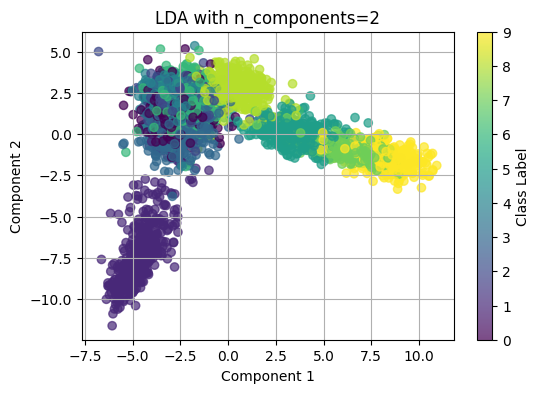

Evaluating LDA with n_components=3...


Evaluating LDA with n_components=5...


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

for n in n_components[:3]:
    print(f"Evaluating LDA with n_components={n}...")
    lda = LinearDiscriminantAnalysis(n_components=n)
    X_train_lda, X_test_lda = lda.fit_transform(evaluator_small.X_train, evaluator_small.y_train), lda.transform(evaluator_small.X_test)
    reductions[f'LDA_{n}'] = (X_train_lda, X_test_lda)
    kmeans_results[f'LDA_{n}'] = evaluator_small._evaluate_reduction_with_kmeans(X_train_lda, X_test_lda)
    logistic_regression_results[f'LDA_{n}'] = evaluator_small.predict_on_reduced_with_logistic_regression(X_train_lda, X_test_lda)
    knn_results[f'LDA_{n}'] = evaluator_small._evaluate_knn_classification(X_train_lda, X_test_lda)
    if n == 2:
        plot_2d_projection(X_train_lda, evaluator_small.y_train, title=f'LDA with n_components={n}')
        plt.show()
    if n == 3:
        plot_3d_interactive(X_train_lda, evaluator_small.y_train, title=f'LDA with n_components={n}')



Evaluating PCA with n_components=2...


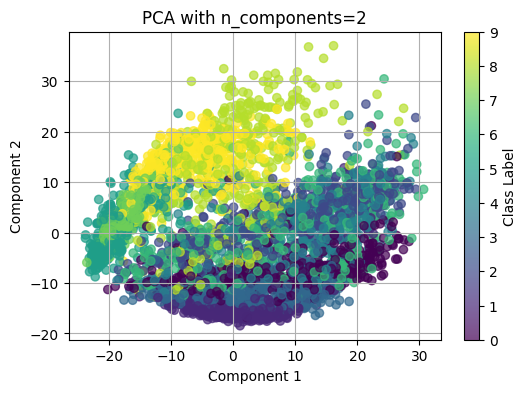

Evaluating PCA with n_components=3...


Evaluating PCA with n_components=5...
Evaluating PCA with n_components=10...
Evaluating PCA with n_components=20...
Evaluating PCA with n_components=50...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
from sklearn.decomposition import PCA
for n in n_components:
    print(f"Evaluating PCA with n_components={n}...")
    pca = PCA(n_components=n)
    X_train_pca, X_test_pca = pca.fit_transform(evaluator_small.X_train), pca.transform(evaluator_small.X_test)
    reductions[f'PCA_{n}'] = (X_train_pca, X_test_pca)
    kmeans_results[f'PCA_{n}'] = evaluator_small._evaluate_reduction_with_kmeans(X_train_pca, X_test_pca)
    logistic_regression_results[f'PCA_{n}'] = evaluator_small.predict_on_reduced_with_logistic_regression(X_train_pca, X_test_pca)
    knn_results[f'PCA_{n}'] = evaluator_small._evaluate_knn_classification(X_train_pca, X_test_pca)
    if n == 2:
        plot_2d_projection(X_train_pca, evaluator_small.y_train, title=f'PCA with n_components={n}')
        plt.show()
    elif n == 3:
        plot_3d_interactive(X_train_pca, evaluator_small.y_train, title=f'PCA with n_components={n}')


KernelPCA nie udało się liczyć na całym zbiorze dlatego wybeiramy podzbiór 

Evaluating kernelPCA with n_components=2...


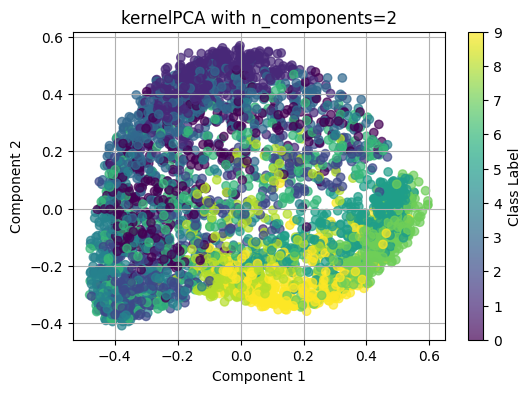

Evaluating kernelPCA with n_components=3...


Evaluating kernelPCA with n_components=5...
Evaluating kernelPCA with n_components=10...
Evaluating kernelPCA with n_components=20...
Evaluating kernelPCA with n_components=50...


In [16]:
from sklearn.decomposition import KernelPCA
for n in n_components:
    print(f"Evaluating kernelPCA with n_components={n}...")
    kpca = KernelPCA(n_components=n, kernel='rbf')
    X_train_kpca, X_test_kpca = kpca.fit_transform(evaluator_small.X_train), kpca.transform(evaluator_small.X_test)
    reductions[f'kernelPCA_{n}'] = (X_train_kpca, X_test_kpca)
    kmeans_results[f'kernelPCA_{n}'] = evaluator_small._evaluate_reduction_with_kmeans(X_train_kpca, X_test_kpca)
    logistic_regression_results[f'kernelPCA_{n}'] = evaluator_small.predict_on_reduced_with_logistic_regression(X_train_kpca, X_test_kpca)
    knn_results[f'kernelPCA_{n}'] = evaluator_small._evaluate_knn_classification(X_train_kpca, X_test_kpca)
    if n == 2:
        plot_2d_projection(X_train_kpca, evaluator_small.y_train, title=f'kernelPCA with n_components={n}')
        plt.show()
    elif n == 3:
        plot_3d_interactive(X_train_kpca, evaluator_small.y_train, title=f'kernelPCA with n_components={n}')

Evaluating Autoencoder with n_components=2...


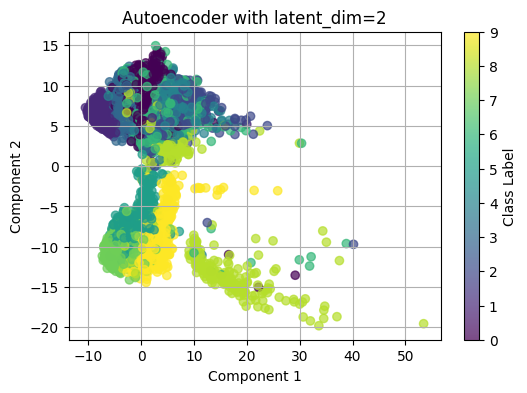

Evaluating Autoencoder with n_components=3...


Evaluating Autoencoder with n_components=5...
Evaluating Autoencoder with n_components=10...
Evaluating Autoencoder with n_components=20...
Evaluating Autoencoder with n_components=50...


In [20]:
from utils.autoencoder import TorchAutoencoderReducer
for n in n_components:
    print(f"Evaluating Autoencoder with n_components={n}...")
    input_dim=evaluator_small.X_train.shape[1]
    latent_dim=n
    reducer = TorchAutoencoderReducer(input_dim=input_dim, latent_dim=latent_dim)
    X_train_ae = reducer.fit_transform(evaluator_small.X_train)
    X_test_ae = reducer.transform(evaluator_small.X_test)
    reductions[f'Autoencoder_{latent_dim}'] = (X_train_ae, X_test_ae)
    kmeans_results[f'Autoencoder_{latent_dim}'] = evaluator_small._evaluate_reduction_with_kmeans(X_train_ae, X_test_ae)
    logistic_regression_results[f'Autoencoder_{latent_dim}'] = evaluator_small.predict_on_reduced_with_logistic_regression(X_train_ae, X_test_ae)
    knn_results[f'Autoencoder_{latent_dim}'] = evaluator_small._evaluate_knn_classification(X_train_ae, X_test_ae)
    if n == 2:
        plot_2d_projection(X_train_ae, evaluator_small.y_train, title=f'Autoencoder with latent_dim={latent_dim}')
        plt.show()
    elif n == 3:
        plot_3d_interactive(X_train_ae, evaluator_small.y_train, title=f'Autoencoder with latent_dim={latent_dim}')


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Evaluating UMAP with n_components=2...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


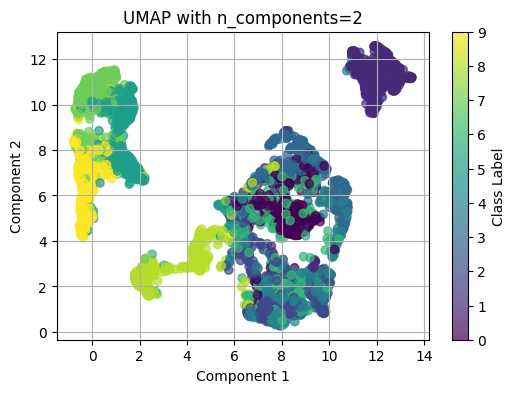

Evaluating UMAP with n_components=3...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Evaluating UMAP with n_components=5...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Evaluating UMAP with n_components=10...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Evaluating UMAP with n_components=20...
Evaluating UMAP with n_components=50...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [21]:
from umap import UMAP

for n in n_components:
    print(f"Evaluating UMAP with n_components={n}...")
    umap_reducer = UMAP(n_components=n, random_state=42)
    X_train_umap = umap_reducer.fit_transform(evaluator_small.X_train)
    X_test_umap = umap_reducer.transform(evaluator_small.X_test)
    reductions[f'UMAP_{n}'] = (X_train_umap, X_test_umap)
    kmeans_results[f'UMAP_{n}'] = evaluator_small._evaluate_reduction_with_kmeans(X_train_umap, X_test_umap)
    logistic_regression_results[f'UMAP_{n}'] = evaluator_small.predict_on_reduced_with_logistic_regression(X_train_umap, X_test_umap)
    knn_results[f'UMAP_{n}'] = evaluator_small._evaluate_knn_classification(X_train_umap, X_test_umap)
    if n == 2:
        plot_2d_projection(X_train_umap, evaluator_small.y_train, title=f'UMAP with n_components={n}')
        plt.show()
    elif n == 3:
        plot_3d_interactive(X_train_umap, evaluator_small.y_train, title=f'UMAP with n_components={n}')

Evaluating Isomap with n_components=2...


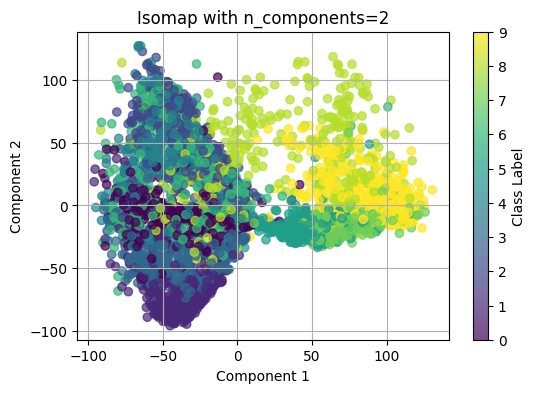

Evaluating Isomap with n_components=3...


Evaluating Isomap with n_components=5...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluating Isomap with n_components=10...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluating Isomap with n_components=20...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluating Isomap with n_components=50...


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.manifold import Isomap
for n in n_components:
    print(f"Evaluating Isomap with n_components={n}...")
    isomap = Isomap(n_components=n, max_iter=5000)
    X_train_isomap = isomap.fit_transform(evaluator_small.X_train)
    X_test_isomap = isomap.transform(evaluator_small.X_test)
    reductions[f'Isomap_{n}'] = (X_train_isomap, X_test_isomap)
    kmeans_results[f'Isomap_{n}'] = evaluator_small._evaluate_reduction_with_kmeans(X_train_isomap, X_test_isomap)
    logistic_regression_results[f'Isomap_{n}'] = evaluator_small.predict_on_reduced_with_logistic_regression(X_train_isomap, X_test_isomap)
    knn_results[f'Isomap_{n}'] = evaluator_small._evaluate_knn_classification(X_train_isomap, X_test_isomap)
    if n == 2:
        plot_2d_projection(X_train_isomap, evaluator_small.y_train, title=f'Isomap with n_components={n}')
        plt.show()
    elif n == 3:
        plot_3d_interactive(X_train_isomap, evaluator_small.y_train, title=f'Isomap with n_components={n}')


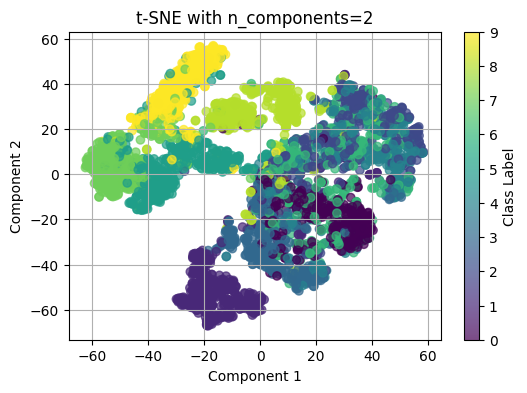

In [ ]:
from sklearn.manifold import TSNE
tsne2d = TSNE(n_components=2, random_state=42)
X_train_tsne2d = tsne2d.fit_transform(evaluator_small.X_train)
plot_2d_projection(X_train_tsne2d, evaluator_small.y_train, title='t-SNE with n_components=2')
plt.show()
tsne3d = TSNE(n_components=3, random_state=42)
X_train_tsne3d = tsne3d.fit_transform(evaluator_small.X_train)
plot_3d_interactive(X_train_tsne3d, evaluator_small.y_train, title='t-SNE with n_components=3')

Sprawdźmy trustworthiness

In [42]:
from sklearn.manifold import trustworthiness
trustworthiness_results = {key: trustworthiness(reductions[key][0], evaluator_small.X_train) for key in reductions.keys()}

In [53]:
int('1f77b4',16)
hex(int('1f77b4',16))

'0x1f77b4'

/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_73406/3846965990.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(trustworthiness_results.keys(), rotation=45, ha='right')


[Text(0, 0, 'LDA_2'),
 Text(1, 0, 'LDA_3'),
 Text(2, 0, 'LDA_5'),
 Text(3, 0, 'PCA_2'),
 Text(4, 0, 'PCA_3'),
 Text(5, 0, 'PCA_5'),
 Text(6, 0, 'PCA_10'),
 Text(7, 0, 'PCA_20'),
 Text(8, 0, 'PCA_50'),
 Text(9, 0, 'kernelPCA_2'),
 Text(10, 0, 'kernelPCA_3'),
 Text(11, 0, 'kernelPCA_5'),
 Text(12, 0, 'kernelPCA_10'),
 Text(13, 0, 'kernelPCA_20'),
 Text(14, 0, 'kernelPCA_50'),
 Text(15, 0, 'Autoencoder_2'),
 Text(16, 0, 'Autoencoder_3'),
 Text(17, 0, 'Autoencoder_5'),
 Text(18, 0, 'Autoencoder_10'),
 Text(19, 0, 'Autoencoder_20'),
 Text(20, 0, 'Autoencoder_50'),
 Text(21, 0, 'UMAP_2'),
 Text(22, 0, 'UMAP_3'),
 Text(23, 0, 'UMAP_5'),
 Text(24, 0, 'UMAP_10'),
 Text(25, 0, 'UMAP_20'),
 Text(26, 0, 'UMAP_50'),
 Text(27, 0, 'Isomap_2'),
 Text(28, 0, 'Isomap_3'),
 Text(29, 0, 'Isomap_5'),
 Text(30, 0, 'Isomap_10'),
 Text(31, 0, 'Isomap_20'),
 Text(32, 0, 'Isomap_50')]

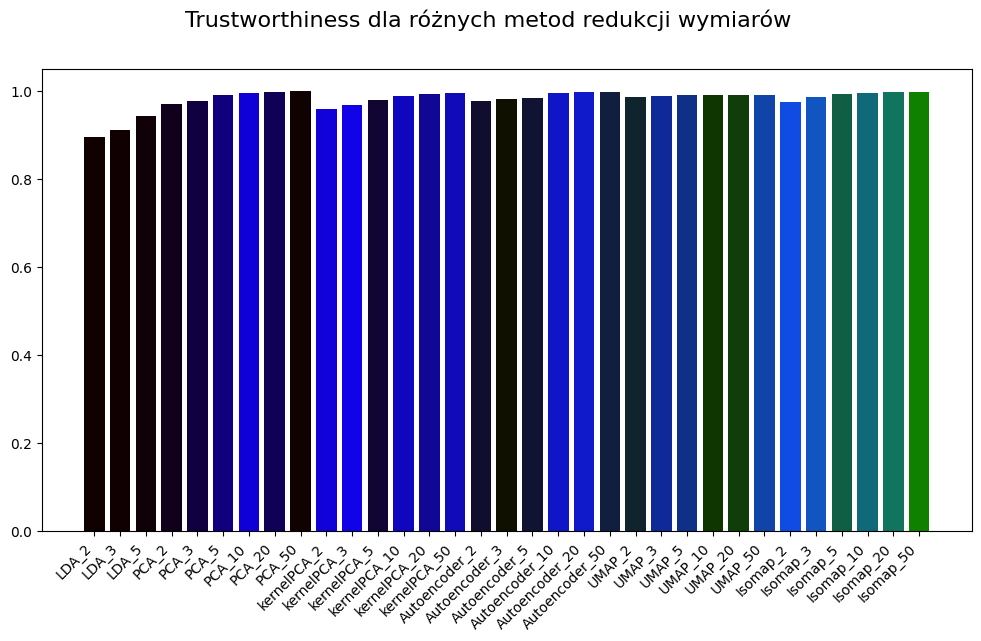

In [91]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Trustworthiness dla różnych metod redukcji wymiarów ", fontsize=16)
ax.bar(trustworthiness_results.keys(), trustworthiness_results.values(), color = ['#'+hex(val**3+16**5)[2:] for val in range(len(trustworthiness_results))])
ax.set_xticklabels(trustworthiness_results.keys(), rotation=45, ha='right')

/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_73406/3385457899.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_73406/3385457899.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


Text(0, 0.5, 'F1 Score')

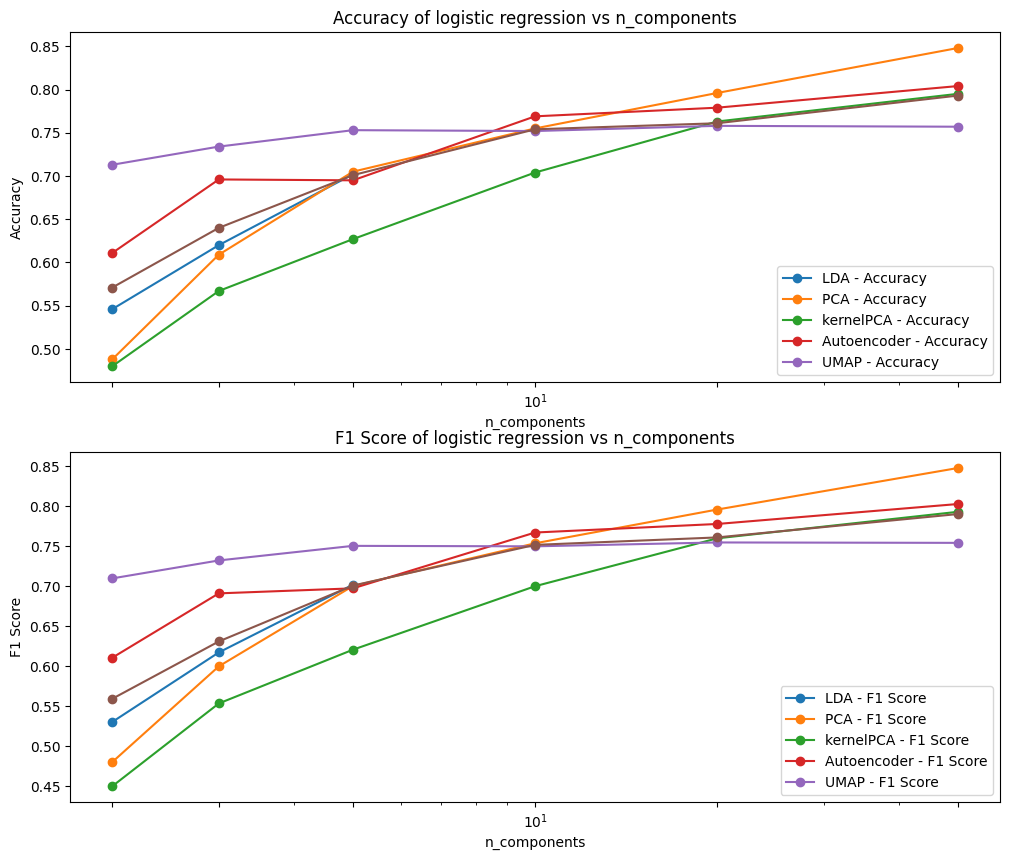

In [111]:
from sklearn.metrics import accuracy_score, f1_score
fig, axes = plt.subplots(2,1,figsize=(12, 10))
for name in ['LDA', 'PCA', 'kernelPCA', 'Autoencoder', 'UMAP', 'Isomap']:
    accuracies = []
    f1_scores = []
    i = 0
    for n in n_components:
        y_pred = logistic_regression_results.get(f'{name}_{n}', None)
        if y_pred is None:
            continue
        acccuracy = accuracy_score(evaluator_small.y_test, y_pred)
        f1 = f1_score(evaluator_small.y_test, y_pred, average='weighted')
        accuracies.append(acccuracy)
        f1_scores.append(f1)
        i+=1
    axes[0].legend()
    axes[1].legend()
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')
    axes[0].set_xticks([2, 3, 5, 10, 20, 50])
    axes[1].set_xticks([2, 3, 5, 10, 20, 50])

   
    axes[0].set_title('Accuracy of logistic regression vs n_components')
    axes[1].set_title('F1 Score of logistic regression vs n_components')
    
    axes[0].plot(n_components[:i], accuracies, label=f'{name} - Accuracy', marker='o')
    axes[1].plot(n_components[:i], f1_scores, label=f'{name} - F1 Score', marker='o')
axes[0].set_xlabel('n_components')
axes[0].set_ylabel('Accuracy')
axes[1].set_xlabel('n_components')
axes[1].set_ylabel('F1 Score')

/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_73406/3540140903.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_73406/3540140903.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


Text(0, 0.5, 'F1 Score')

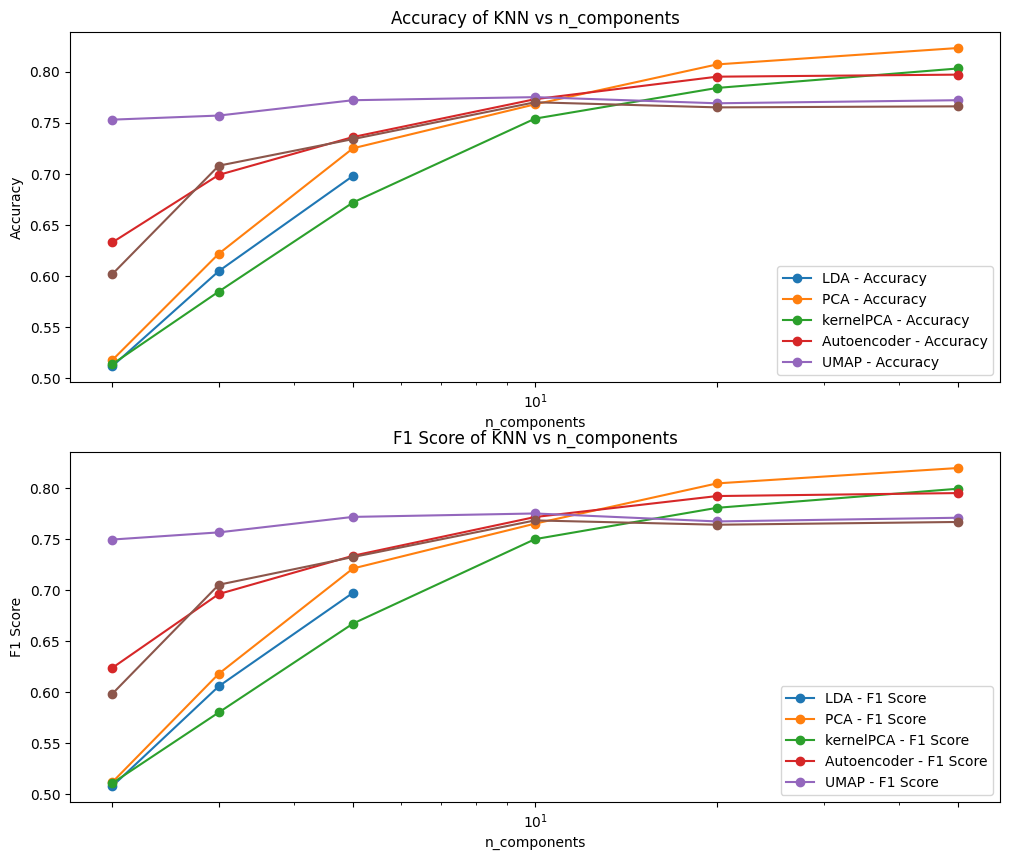

In [112]:

fig, axes = plt.subplots(2,1,figsize=(12, 10))
for name in ['LDA', 'PCA', 'kernelPCA', 'Autoencoder', 'UMAP', 'Isomap']:
    accuracies = []
    f1_scores = []
    i = 0
    for n in n_components:
        y_pred = knn_results.get(f'{name}_{n}', None)
        if y_pred is None:
            continue
        acccuracy = accuracy_score(evaluator_small.y_test, y_pred)
        f1 = f1_score(evaluator_small.y_test, y_pred, average='weighted')
        accuracies.append(acccuracy)
        f1_scores.append(f1)
        i+=1
    axes[0].legend()
    axes[1].legend()
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')
    axes[0].set_xticks([2, 3, 5, 10, 20, 50])
    axes[1].set_xticks([2, 3, 5, 10, 20, 50])

   
    axes[0].set_title('Accuracy of KNN vs n_components')
    axes[1].set_title('F1 Score of KNN vs n_components')
    
    axes[0].plot(n_components[:i], accuracies, label=f'{name} - Accuracy', marker='o')
    axes[1].plot(n_components[:i], f1_scores, label=f'{name} - F1 Score', marker='o')
axes[0].set_xlabel('n_components')
axes[0].set_ylabel('Accuracy')
axes[1].set_xlabel('n_components')
axes[1].set_ylabel('F1 Score')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33],
 [Text(0, 0, 'original'),
  Text(1, 0, 'LDA_2'),
  Text(2, 0, 'LDA_3'),
  Text(3, 0, 'LDA_5'),
  Text(4, 0, 'PCA_2'),
  Text(5, 0, 'PCA_3'),
  Text(6, 0, 'PCA_5'),
  Text(7, 0, 'PCA_10'),
  Text(8, 0, 'PCA_20'),
  Text(9, 0, 'PCA_50'),
  Text(10, 0, 'kernelPCA_2'),
  Text(11, 0, 'kernelPCA_3'),
  Text(12, 0, 'kernelPCA_5'),
  Text(13, 0, 'kernelPCA_10'),
  Text(14, 0, 'kernelPCA_20'),
  Text(15, 0, 'kernelPCA_50'),
  Text(16, 0, 'Autoencoder_2'),
  Text(17, 0, 'Autoencoder_3'),
  Text(18, 0, 'Autoencoder_5'),
  Text(19, 0, 'Autoencoder_10'),
  Text(20, 0, 'Autoencoder_20'),
  Text(21, 0, 'Autoencoder_50'),
  Text(22, 0, 'UMAP_2'),
  Text(23, 0, 'UMAP_3'),
  Text(24, 0, 'UMAP_5'),
  Text(25, 0, 'UMAP_10'),
  Text(26, 0, 'UMAP_20'),
  Text(27, 0, 'UMAP_50'),
  Text(28, 0, 'Isomap_2'),
  Text(29, 

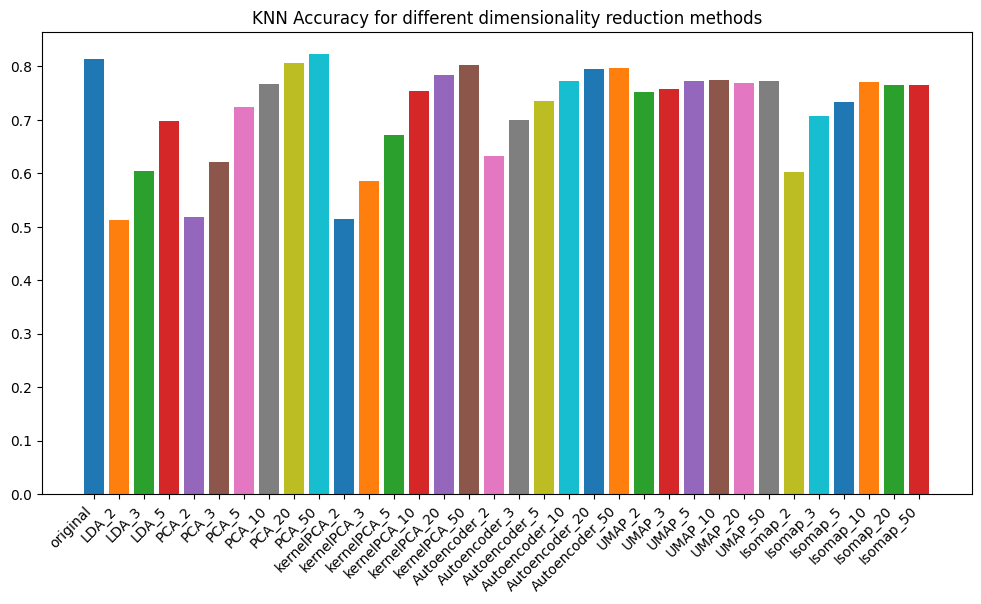

In [121]:
plt.figure(figsize=(12, 6))
plt.title('KNN Accuracy for different dimensionality reduction methods')
for key in knn_results.keys():
    plt.bar(key, accuracy_score(evaluator_small.y_test, knn_results[key]))
plt.xticks(rotation=45, ha='right')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33],
 [Text(0, 0, 'original'),
  Text(1, 0, 'LDA_2'),
  Text(2, 0, 'LDA_3'),
  Text(3, 0, 'LDA_5'),
  Text(4, 0, 'PCA_2'),
  Text(5, 0, 'PCA_3'),
  Text(6, 0, 'PCA_5'),
  Text(7, 0, 'PCA_10'),
  Text(8, 0, 'PCA_20'),
  Text(9, 0, 'PCA_50'),
  Text(10, 0, 'kernelPCA_2'),
  Text(11, 0, 'kernelPCA_3'),
  Text(12, 0, 'kernelPCA_5'),
  Text(13, 0, 'kernelPCA_10'),
  Text(14, 0, 'kernelPCA_20'),
  Text(15, 0, 'kernelPCA_50'),
  Text(16, 0, 'Autoencoder_2'),
  Text(17, 0, 'Autoencoder_3'),
  Text(18, 0, 'Autoencoder_5'),
  Text(19, 0, 'Autoencoder_10'),
  Text(20, 0, 'Autoencoder_20'),
  Text(21, 0, 'Autoencoder_50'),
  Text(22, 0, 'UMAP_2'),
  Text(23, 0, 'UMAP_3'),
  Text(24, 0, 'UMAP_5'),
  Text(25, 0, 'UMAP_10'),
  Text(26, 0, 'UMAP_20'),
  Text(27, 0, 'UMAP_50'),
  Text(28, 0, 'Isomap_2'),
  Text(29, 

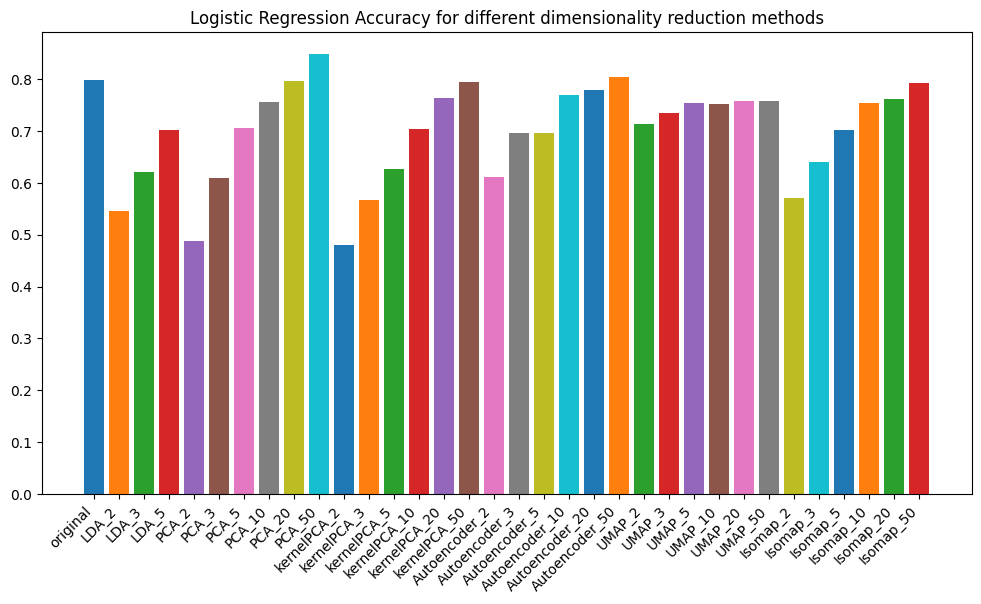

In [122]:
plt.figure(figsize=(12, 6))
plt.title('Logistic Regression Accuracy for different dimensionality reduction methods')
for key in logistic_regression_results.keys():
    plt.bar(key, accuracy_score(evaluator_small.y_test, logistic_regression_results[key]))
plt.xticks(rotation=45, ha='right')